In [1]:
import sys
from pathlib import Path
import pandas as pd
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

sys.path.append("..")
from src.metrics import mae, rmse

PROCESSED = Path("../data/processed")
RESULTS = Path("../results")

HORIZON = 72
TARGET = "price_mwh"
TEST_START = pd.Timestamp("2025-10-01")

data = pd.read_csv(PROCESSED / f"features_h{HORIZON}.csv", parse_dates=["hour_end"]).set_index("hour_end")
X = data.drop(columns=[TARGET])    # the 18 inputs
y = data[TARGET]                   # the price to predict
print(X.shape, y.shape)

(15575, 18) (15575,)


In [2]:
# Leave a gap of one horizon (72 h) before the test period. At the start of the
# test period, the most recent 72 hours of prices would not yet be known.
train_end = TEST_START - pd.Timedelta(hours=HORIZON)

X_train, y_train = X[X.index < train_end], y[y.index < train_end]
X_test, y_test = X[X.index >= TEST_START], y[y.index >= TEST_START]

print("Training rows:", len(X_train), "from", X_train.index.min(), "to", X_train.index.max())
print("Test rows:", len(X_test), "from", X_test.index.min(), "to", X_test.index.max())

Training rows: 6887 from 2024-12-15 01:00:00 to 2025-09-27 23:00:00
Test rows: 8616 from 2025-10-01 00:00:00 to 2026-09-24 23:00:00


In [3]:
def scaled_svr(C):
    """SVR with both the inputs and the price rescaled, which it needs to work well."""
    return TransformedTargetRegressor(
        regressor=make_pipeline(StandardScaler(), SVR(kernel="rbf", C=C, epsilon=0.1)),
        transformer=StandardScaler(),
    )

# Trial period: the last 60 days of the training window
val_start = train_end - pd.Timedelta(days=60)
X_fit, y_fit = X_train[X_train.index < val_start], y_train[y_train.index < val_start]
X_val, y_val = X_train[X_train.index >= val_start], y_train[y_train.index >= val_start]

tree_scores = {}
for depth in [3, 5, 8, 12, 16]:
    for leaf in [20, 50, 100]:
        tree = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=leaf, random_state=0).fit(X_fit, y_fit)
        tree_scores[(depth, leaf)] = mae(y_val, tree.predict(X_val))
best_tree = min(tree_scores, key=tree_scores.get)

svr_scores = {}
for C in [0.03, 0.1, 0.3, 1, 3]:
    svr = scaled_svr(C).fit(X_fit, y_fit)
    svr_scores[C] = mae(y_val, svr.predict(X_val))
best_C = min(svr_scores, key=svr_scores.get)

print("Best tree (depth, min leaf size):", best_tree, "| trial MAE:", round(tree_scores[best_tree], 1))
print("SVR trial MAE by penalty C:", {c: round(s, 1) for c, s in svr_scores.items()})
print("Best C:", best_C)

Best tree (depth, min leaf size): (8, 100) | trial MAE: 45.6
SVR trial MAE by penalty C: {0.03: 32.9, 0.1: 32.8, 0.3: 33.1, 1: 35.2, 3: 40.1}
Best C: 0.1


In [4]:
models = {
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Decision tree": DecisionTreeRegressor(max_depth=best_tree[0], min_samples_leaf=best_tree[1], random_state=0),
    "SVR": scaled_svr(best_C),
}

predictions = pd.DataFrame({"actual": y_test})
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

baseline = pd.read_csv(RESULTS / "baseline_forecast.csv", parse_dates=["hour_end"]).set_index("hour_end")
predictions["Baseline"] = baseline["baseline"].reindex(predictions.index)

predictions.to_csv(RESULTS / f"predictions_h{HORIZON}_first_fit.csv")

scores = pd.DataFrame(
    [(name, mae(predictions["actual"], predictions[name]), rmse(predictions["actual"], predictions[name]))
     for name in predictions.columns if name != "actual"],
    columns=["Model", "MAE ($/MWh)", "RMSE ($/MWh)"],
).round(2)
scores

,Model,MAE ($/MWh),RMSE ($/MWh)
0,Linear regression,53.69,78.20
1,Decision tree,50.97,125.03
2,SVR,38.17,61.02
3,Baseline,53.78,91.00


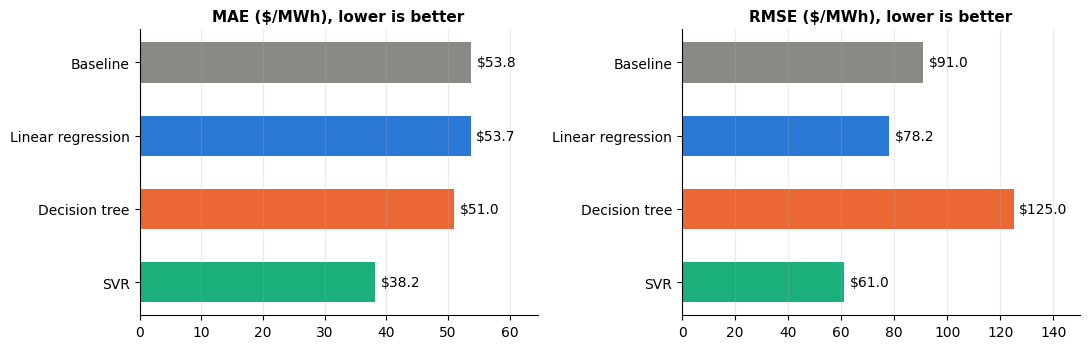

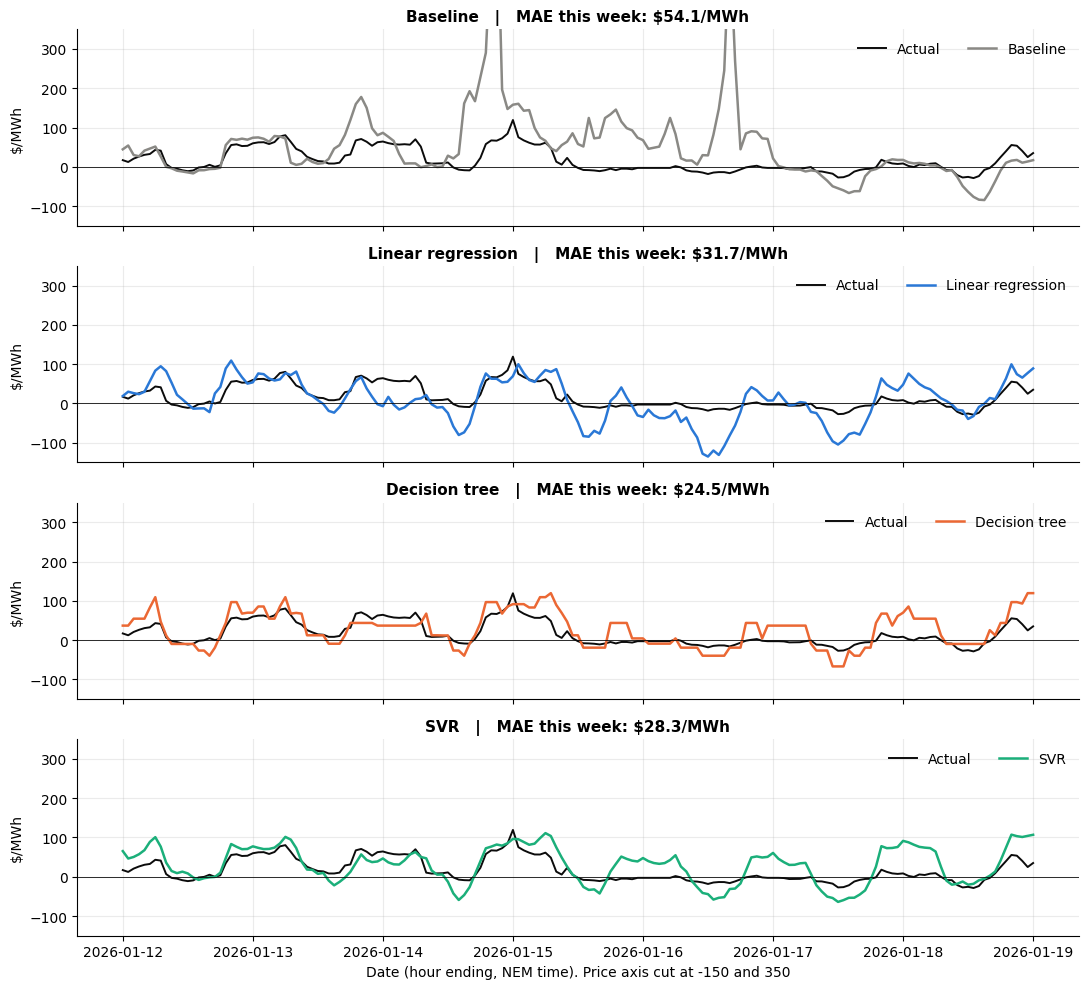

In [5]:
import numpy as np
import matplotlib.pyplot as plt

MODELS = ["Baseline", "Linear regression", "Decision tree", "SVR"]
COLOURS = {
    "Baseline": "#8a8985",
    "Linear regression": "#2a78d6",
    "Decision tree": "#eb6834",
    "SVR": "#1baf7a",
}
INK = "#0b0b0b"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
})

errors = predictions[MODELS].sub(predictions["actual"], axis=0)    # forecast minus actual
scores = pd.DataFrame({
    "MAE": [mae(predictions["actual"], predictions[m]) for m in MODELS],
    "RMSE": [rmse(predictions["actual"], predictions[m]) for m in MODELS],
}, index=MODELS)

# Chart 1: MAE and RMSE for each model
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    bars = ax.barh(MODELS, scores[metric], color=[COLOURS[m] for m in MODELS], height=0.55)
    ax.bar_label(bars, labels=[f"${v:.1f}" for v in scores[metric]], padding=4)
    ax.set_title(f"{metric} ($/MWh), lower is better")
    ax.set_xlim(0, scores[metric].max() * 1.2)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

# Chart 2: one week of forecasts against actual prices
WEEK_START = "2026-01-12"          # change this date to look at any other week
week = predictions.loc[WEEK_START:pd.Timestamp(WEEK_START) + pd.Timedelta(days=7)]

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True, sharey=True)
for ax, m in zip(axes, MODELS):
    ax.plot(week.index, week["actual"], color=INK, linewidth=1.4, label="Actual")
    ax.plot(week.index, week[m], color=COLOURS[m], linewidth=1.8, label=m)
    ax.axhline(0, color=INK, linewidth=0.6)
    week_mae = mae(week["actual"], week[m])
    ax.set_title(f"{m}   |   MAE this week: ${week_mae:.1f}/MWh")
    ax.set_ylabel("$/MWh")
    ax.set_ylim(-150, 350)
    ax.legend(loc="upper right", ncol=2, frameon=False)
axes[-1].set_xlabel("Date (hour ending, NEM time). Price axis cut at -150 and 350")
plt.tight_layout()
plt.show()

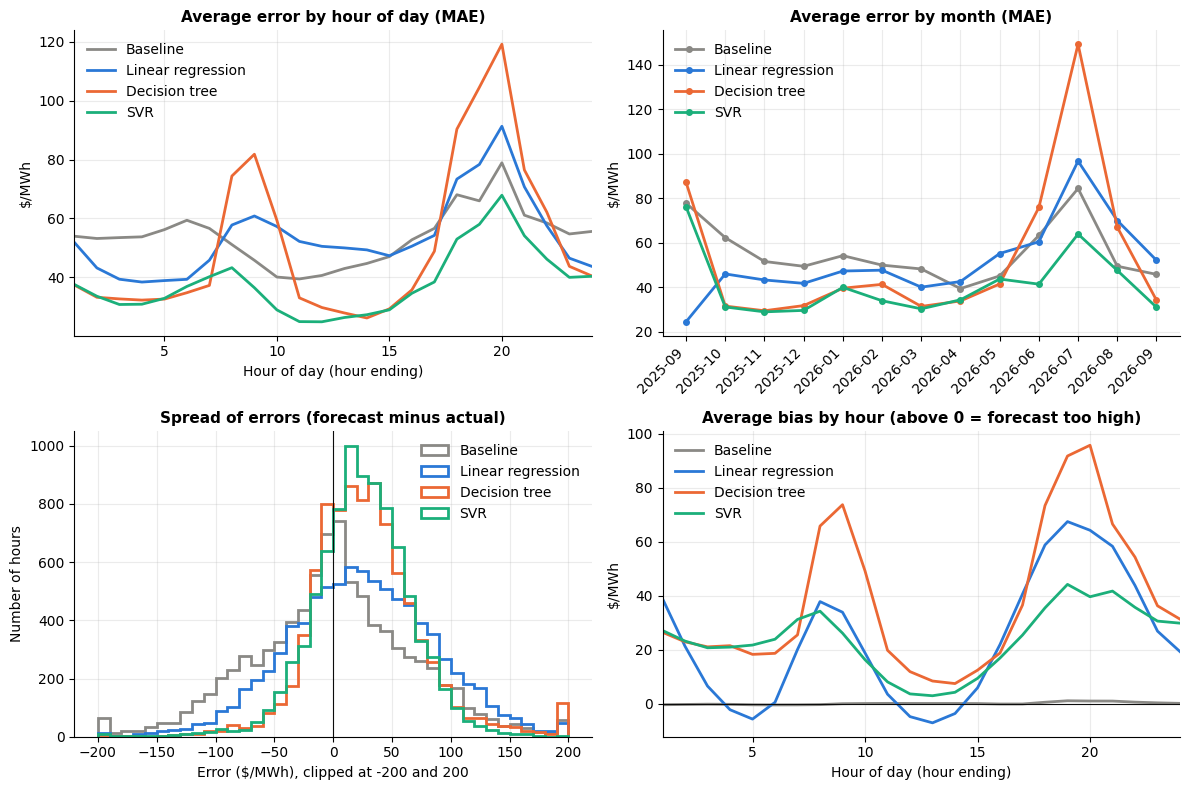

In [6]:
start = predictions.index - pd.Timedelta(hours=1)
hour_ending = start.hour + 1
month = start.to_period("M")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) MAE by hour of day
ax = axes[0, 0]
mae_by_hour = errors.abs().groupby(hour_ending).mean()
for m in MODELS:
    ax.plot(mae_by_hour.index, mae_by_hour[m], color=COLOURS[m], linewidth=2, label=m)
ax.set_title("Average error by hour of day (MAE)")
ax.set_xlabel("Hour of day (hour ending)")
ax.set_ylabel("$/MWh")
ax.set_xlim(1, 24)
ax.legend(frameon=False)

# (b) MAE by month
ax = axes[0, 1]
mae_by_month = errors.abs().groupby(month).mean()
x = np.arange(len(mae_by_month))
for m in MODELS:
    ax.plot(x, mae_by_month[m], color=COLOURS[m], linewidth=2, marker="o", markersize=4, label=m)
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in mae_by_month.index], rotation=45, ha="right")
ax.set_title("Average error by month (MAE)")
ax.set_ylabel("$/MWh")
ax.legend(frameon=False)

# (c) Spread of errors
ax = axes[1, 0]
bins = np.arange(-200, 201, 10)
for m in MODELS:
    ax.hist(errors[m].clip(-200, 200), bins=bins, histtype="step", color=COLOURS[m], linewidth=2, label=m)
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_title("Spread of errors (forecast minus actual)")
ax.set_xlabel("Error ($/MWh), clipped at -200 and 200")
ax.set_ylabel("Number of hours")
ax.legend(frameon=False)

# (d) Bias by hour of day: do models forecast too high or too low?
ax = axes[1, 1]
bias_by_hour = errors.groupby(hour_ending).mean()
for m in MODELS:
    ax.plot(bias_by_hour.index, bias_by_hour[m], color=COLOURS[m], linewidth=2, label=m)
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_title("Average bias by hour (above 0 = forecast too high)")
ax.set_xlabel("Hour of day (hour ending)")
ax.set_ylabel("$/MWh")
ax.set_xlim(1, 24)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()